<a href="https://colab.research.google.com/github/vathanababuji05-netizen/project_1/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv")



In [ ]:
print(df.head())

    Order_ID Customer_ID  Customer_Age Customer_Gender     City     Area  \
0  ORD000001    CUST6948          19.0            Male      NaN  Central   
1  ORD000002    CUST6515           NaN          Female  Chennai    North   
2  ORD000003    CUST1765           NaN            Male    Delhi      NaN   
3  ORD000004    CUST2744           NaN            Male   Mumbai  Central   
4  ORD000005    CUST4389          57.0          Female  Chennai    South   

  Restaurant_ID Restaurant_Name Cuisine_Type  Order_Date  ... Final_Amount  \
0        RES936   Restaurant_29      Chinese  10/20/2024  ...          NaN   
1        RES689  Restaurant_419      Chinese   8/12/2024  ...       4849.0   
2        RES723  Restaurant_244      Arabian   12/8/2024  ...        737.0   
3        RES951  Restaurant_178      Chinese   10/8/2024  ...          NaN   
4        RES419  Restaurant_262      Chinese    2/4/2024  ...        352.0   

   Payment_Mode  Order_Status  Cancellation_Reason  Delivery_Partner_ID  \

In [ ]:
# Data Cleaning
# ----------------------

print(df.shape)
print(df.isnull().sum())

(14322, 25)
Order_ID                   0
Customer_ID                0
Customer_Age            7166
Customer_Gender         3536
City                    2305
Area                    2352
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type            2462
Order_Date               133
Order_Time               304
Delivery_Time_Min       4814
Distance_km             4829
Order_Value             4800
Discount_Applied        2462
Final_Amount            8054
Payment_Mode            2872
Order_Status               0
Cancellation_Reason    13045
Delivery_Partner_ID        1
Delivery_Rating         2303
Restaurant_Rating          1
Order_Day                  1
Peak_Hour               4810
Profit_Margin              1
dtype: int64


In [ ]:

# Remove duplicates
df.drop_duplicates(inplace=True)

In [1]:
# Fill missing values
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

NameError: name 'df' is not defined

In [ ]:
# KPI Analysis
# ----------------------

total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 14322


In [ ]:
# Revenue
total_revenue = df['Final_Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 21422919.0


In [ ]:
# Average Order Value
avg_order_value = df['Final_Amount'].mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 1495.8049853372434


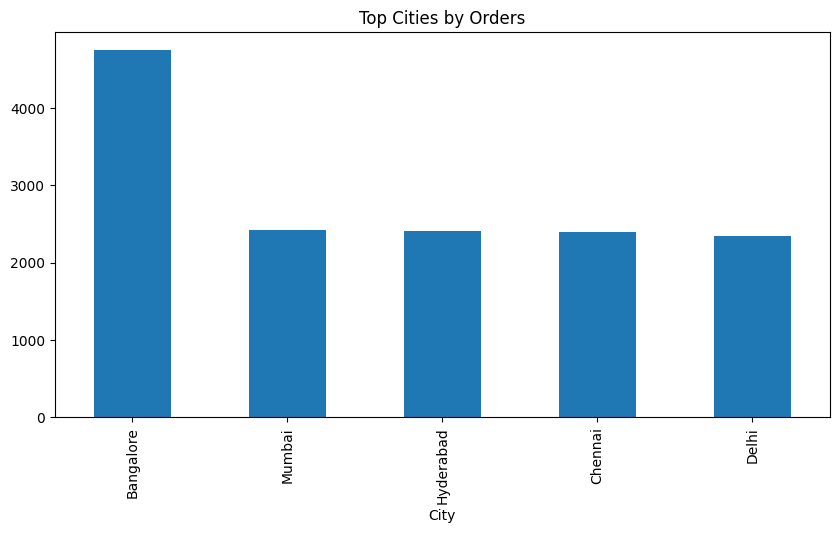

In [ ]:
# City-wise Orders
# ----------------------

city_orders = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
city_orders.plot(kind='bar')
plt.title("Top Cities by Orders")
plt.show()

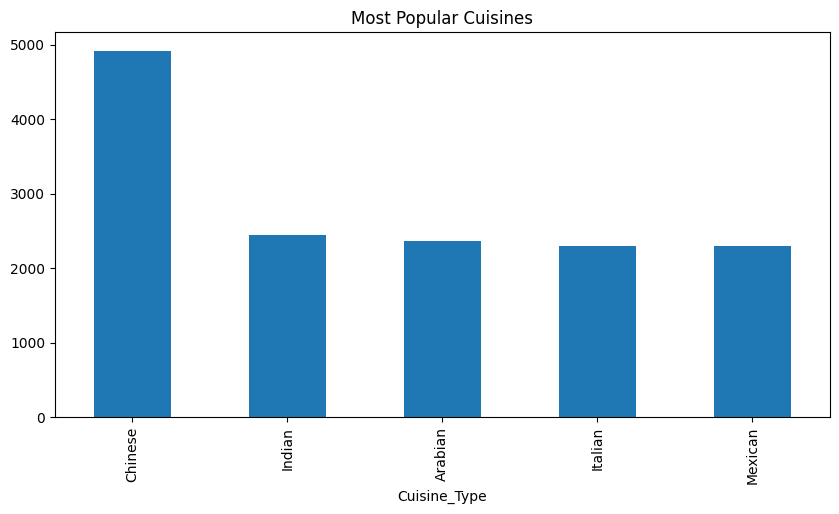

In [ ]:
#Cuisine Analysis
# ----------------------

cuisine = df['Cuisine_Type'].value_counts().head(10)

plt.figure(figsize=(10,5))
cuisine.plot(kind='bar')
plt.title("Most Popular Cuisines")
plt.show()

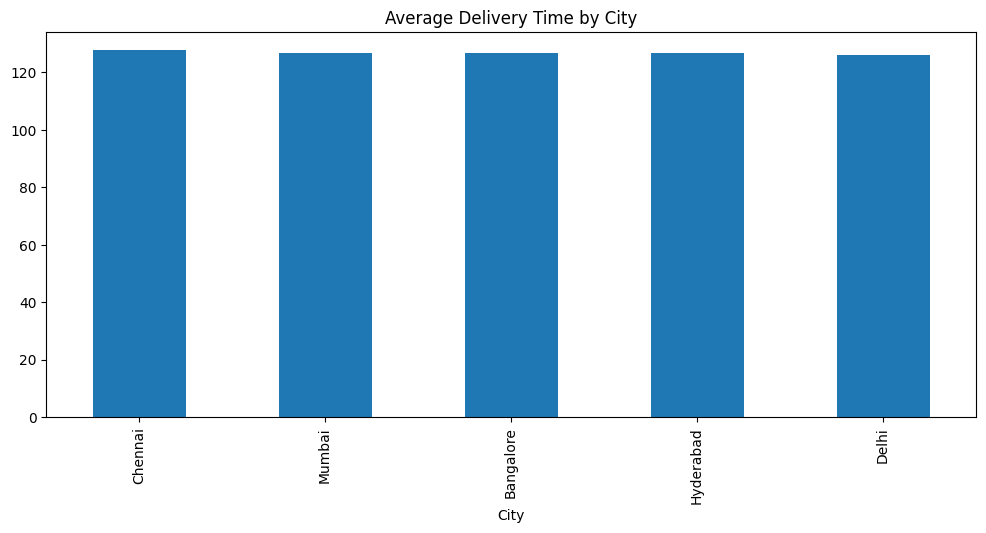

In [ ]:
# Delivery Time Analysis
# ----------------------

avg_delivery = df.groupby('City')['Delivery_Time_Min'].mean()

plt.figure(figsize=(12,5))
avg_delivery.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Delivery Time by City")
plt.show()

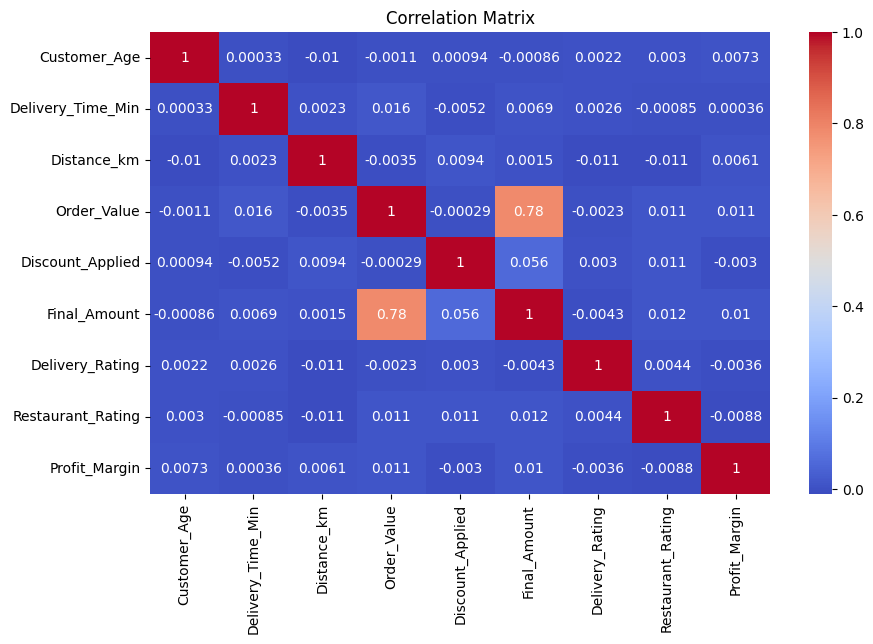

In [ ]:
# Correlation
# ----------------------

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Using SQLite as an alternative for local database storage
# Create an SQLite engine
# This will create a file named 'food_delivery.db' in your Colab environment
sqlite_engine = create_engine('sqlite:///food_delivery.db')

# Upload the DataFrame to the SQLite database
df.to_sql(
        'orders', # Table name
        con=sqlite_engine,
        if_exists='replace', # Replace the table if it already exists
        index=False
)

print("Data Uploaded Successfully to SQLite")

# Optional: Verify by reading data back from SQLite
df_from_sqlite = pd.read_sql('SELECT * FROM orders', sqlite_engine)
print("\nData read from SQLite:")
display(df_from_sqlite.head())

Data Uploaded Successfully to SQLite

Data read from SQLite:


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,None,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,None,DP563,5.0,4.4,Weekend,1.0,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,None,DP369,5.0,4.7,Weekday,1.0,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,None,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,None,DP580,4.0,4.9,Weekend,1.0,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,None,DP728,2.0,4.4,Weekend,0.0,0.12
